# EGX Sentiment Analysis

This notebook is the portfolio narrative for the project. It summarizes the broader experiment window, highlights the lag findings, and surfaces the repo visuals directly inside GitHub.

## Experiment Setup

- Universe: `TMGH`, `COMI`, `ETEL`
- News source: Mubasher stock-news pages
- Price source: Yahoo Finance via `yfinance`
- Window: `2024-01-01` to `2026-03-27`
- Target question: does headline sentiment on day `T` show any relationship with return on day `T+1`?

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
processed_dir = BASE_DIR / 'data' / 'processed'
assets_dir = BASE_DIR / 'docs' / 'assets'

summary = pd.read_csv(processed_dir / 'run_summary.csv')
summary

,ticker,headline_rows,daily_rows,merged_rows
0,TMGH,32,32,31
1,COMI,32,32,31
2,ETEL,23,23,22


In [2]:
ticker_names = {
    'TMGH': 'Talaat Moustafa Group',
    'COMI': 'Commercial International Bank',
    'ETEL': 'Telecom Egypt',
}

lag_frames = []
for ticker in ['TMGH', 'COMI', 'ETEL']:
    lag = pd.read_csv(processed_dir / f'{ticker.lower()}_lag_correlations.csv')
    best_row = lag.loc[lag['pearson_r'].idxmax()].copy()
    lag_frames.append({
        'ticker': ticker,
        'company': ticker_names[ticker],
        'best_lag_days': int(best_row['lag_days']),
        'best_pearson_r': round(float(best_row['pearson_r']), 3),
        'sample_size': int(best_row['sample_size']),
    })

best_lags = pd.DataFrame(lag_frames).sort_values('best_pearson_r', ascending=False)
best_lags

,ticker,company,best_lag_days,best_pearson_r,sample_size
2,ETEL,Telecom Egypt,2,0.301,20
1,COMI,Commercial International Bank,3,0.300,28
0,TMGH,Talaat Moustafa Group,1,-0.184,30


## Interpretation Snapshot

- `COMI` shows the strongest delayed positive relationship in the expanded sample, peaking at a 3-day lag.
- `ETEL` still shows a noticeable 2-day lag signal, but on a smaller sample than `COMI`.
- `TMGH` trends weakly negative across all tested lags in the broader window.
- This remains an exploratory study, not a trading strategy claim.

### TMGH Sentiment vs Closing Price

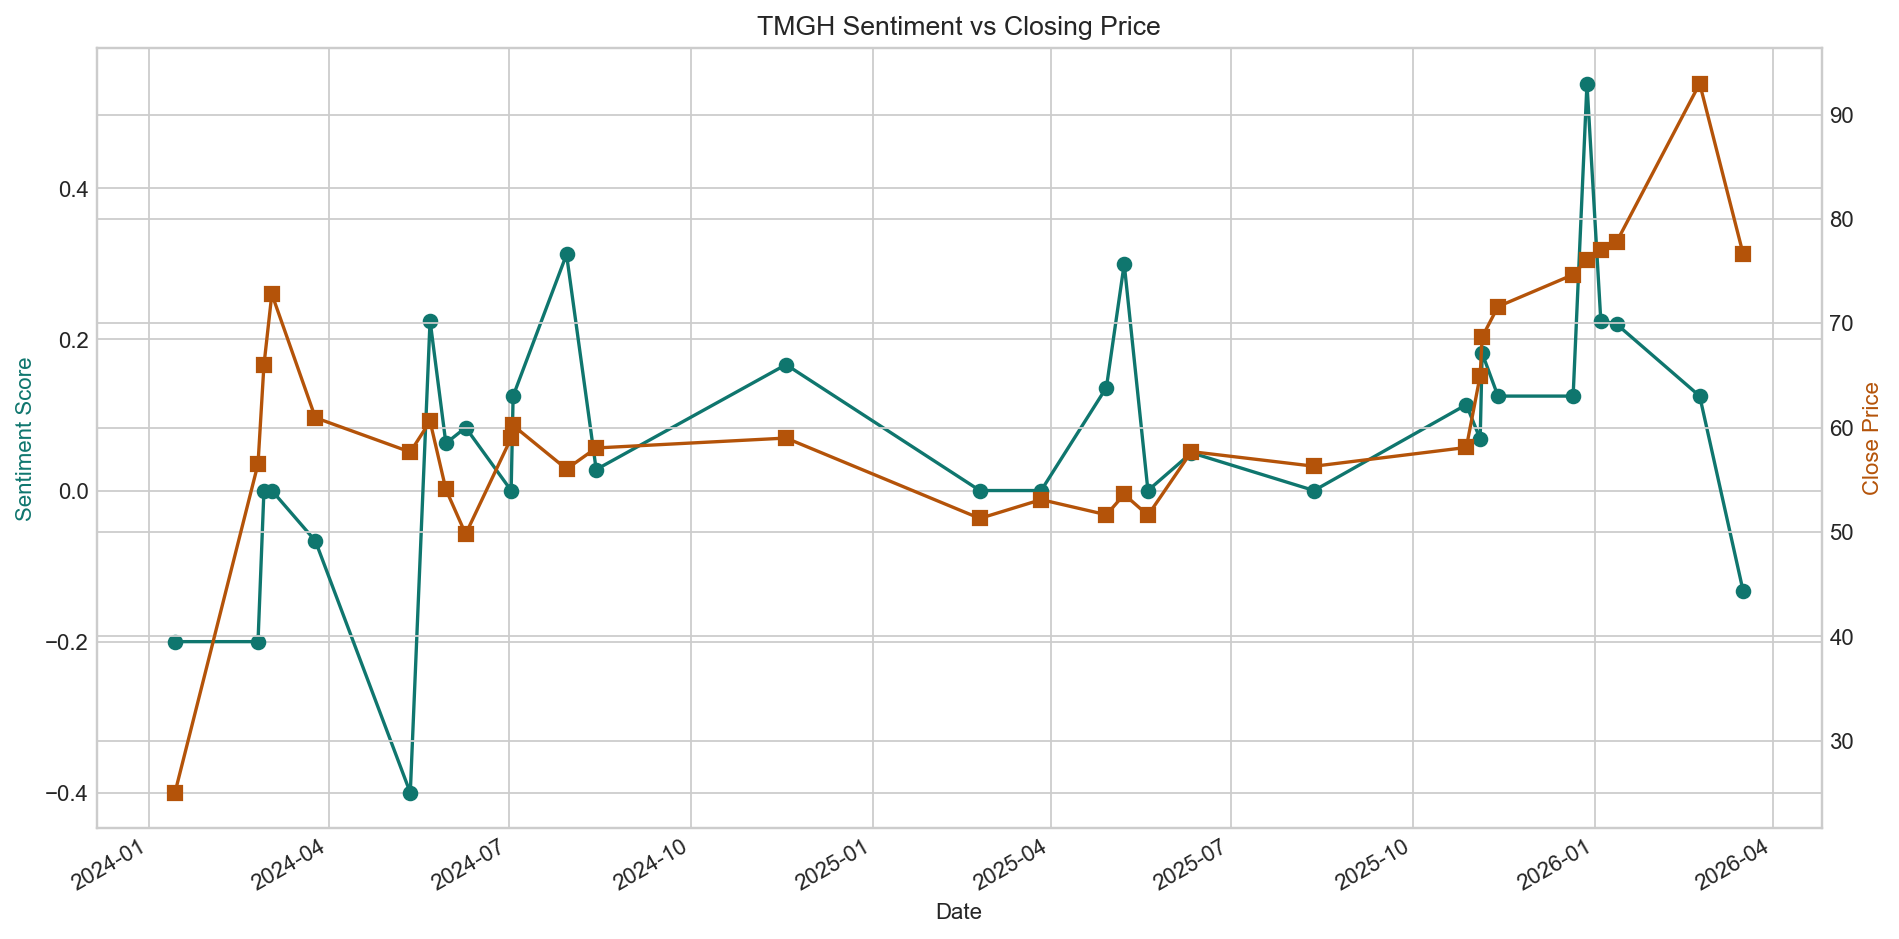

### COMI Lag Correlations

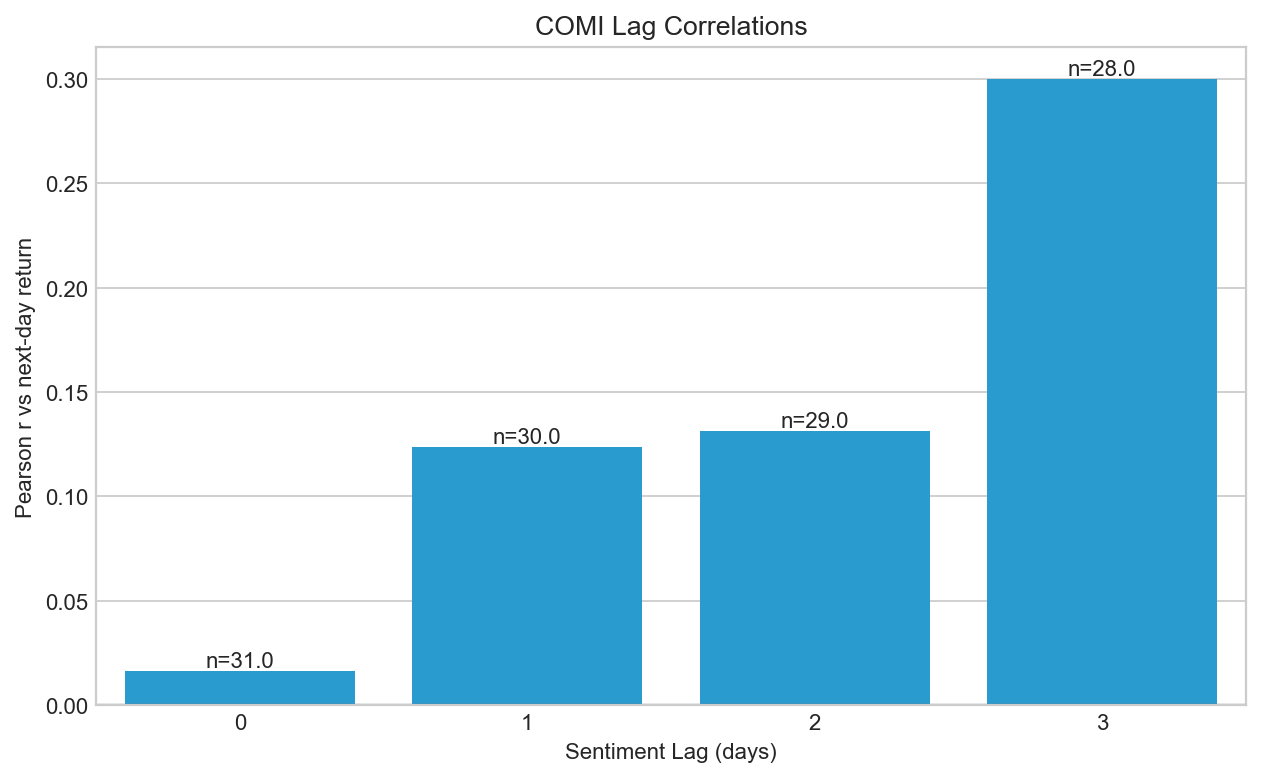

### ETEL Sentiment vs Next-Day Return

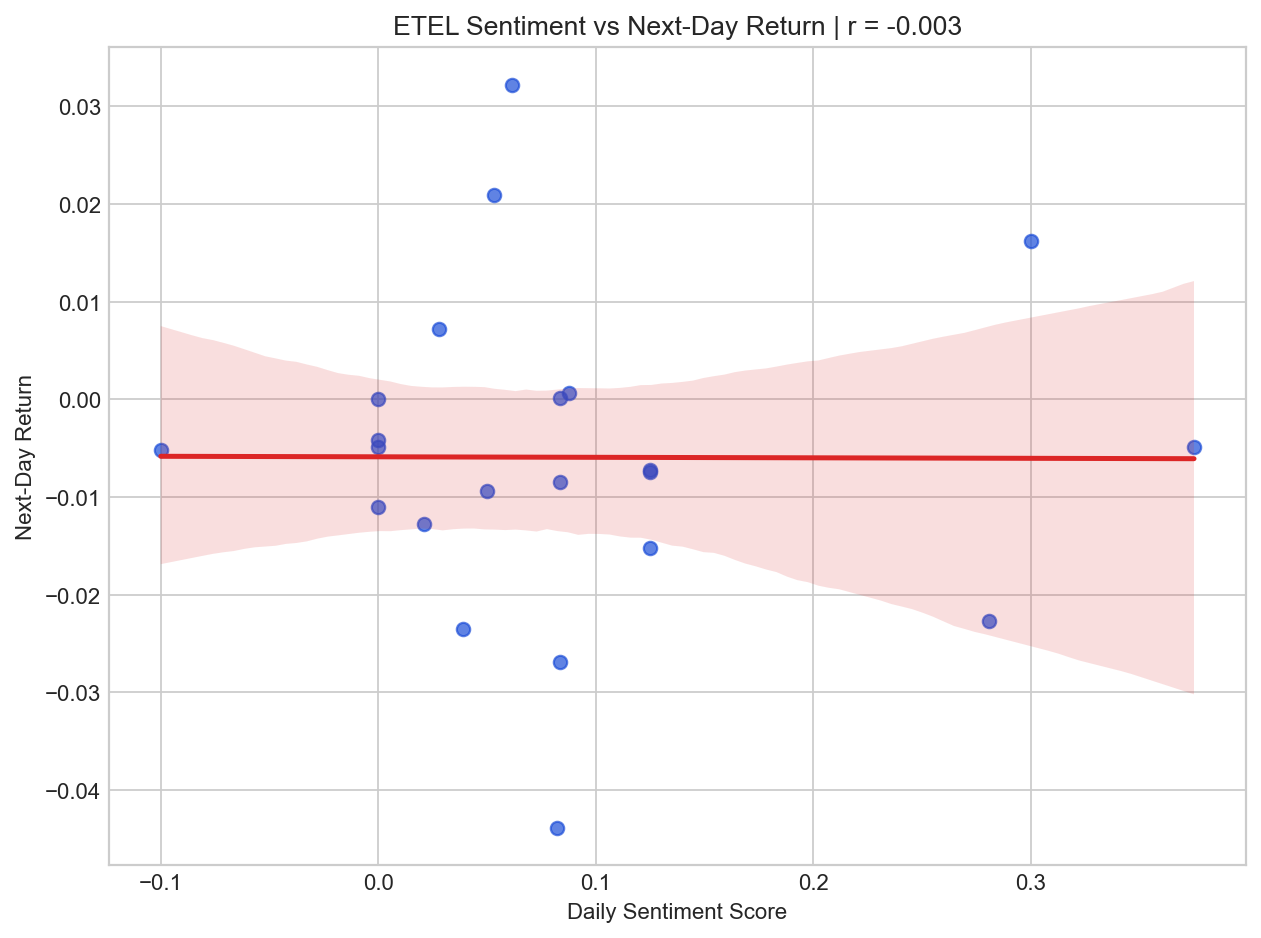

In [3]:
display(Markdown('### TMGH Sentiment vs Closing Price'))
display(Image(filename=str(assets_dir / 'tmgh_sentiment_vs_close.png')))

display(Markdown('### COMI Lag Correlations'))
display(Image(filename=str(assets_dir / 'comi_lag_correlations.png')))

display(Markdown('### ETEL Sentiment vs Next-Day Return'))
display(Image(filename=str(assets_dir / 'etel_scatter.png')))

In [4]:
merged_tables = {}
for ticker in ['TMGH', 'COMI', 'ETEL']:
    merged_tables[ticker] = pd.read_csv(processed_dir / f'{ticker.lower()}_merged.csv', parse_dates=['date'])

recent_snapshot = pd.concat(
    [
        frame.assign(ticker=ticker)[['ticker', 'date', 'headline_count', 'sentiment_score', 'next_day_return']].tail(3)
        for ticker, frame in merged_tables.items()
    ],
    ignore_index=True,
)
recent_snapshot

,ticker,date,headline_count,sentiment_score,next_day_return
0,TMGH,2026-01-12,1,0.220202,0.008740
1,TMGH,2026-02-23,1,0.125000,-0.015812
2,TMGH,2026-03-17,1,-0.133333,0.031062
3,COMI,2026-02-24,1,0.035000,-0.039985
4,COMI,2026-03-17,1,0.087500,0.085265
5,COMI,2026-03-25,1,0.200000,-0.007937
6,ETEL,2026-02-24,1,0.082143,-0.043876
7,ETEL,2026-02-26,1,0.083333,-0.026835
8,ETEL,2026-03-05,1,0.280833,-0.022727


## Limitations

- Headlines per ticker are still limited, even after expanding the sample window.
- The Arabic scorer is stronger than the initial fallback, but it is still lexicon-based rather than transformer-based.
- Correlation alone is not enough to claim predictive power or tradability.
- Mubasher page structure may shift over time, so scraper maintenance is still a live concern.